
Hindi Answer:
LLM का मतलब **लार्ज लैंग्वेज मॉडल** है।

यह आर्टिफिशियल इंटेलिजेंस (AI) प्रोग्राम का एक प्रकार है जिसे खास तौर पर इंसानी भाषा को समझने, बनाने और बदलने के लिए डिज़ाइन किया गया है।

इसका मतलब क्या है, यह नीचे बताया गया है:

1.  **लार्ज (बड़ा):**
    *   **डेटा:** LLM को बहुत बड़ी मात्रा में टेक्स्ट डेटा पर प्रशिक्षित किया जाता है – किताबों, लेखों, वेबसाइटों, बातचीत और कई अन्य स्रोतों से अरबों या खरबों शब्द।
    *   **पैरामीटर्स:** इनमें अरबों या खरबों "पैरामीटर्स" होते हैं, जो वे मान होते हैं जिन्हें मॉडल प्रशिक्षण के दौरान सीखता और समायोजित करता है। ज़्यादा पैरामीटर्स आमतौर पर मॉडल को भाषा में ज़्यादा जटिल पैटर्न और संबंधों को सीखने में मदद करते हैं।

2.  **लैंग्वेज (भाषा):**
    *   उनका मुख्य क्षेत्र इंसानी भाषा है। वे व्याकरण, वाक्य-विन्यास, अर्थ-विज्ञान (शब्दों और वाक्यों का अर्थ), संदर्भ और यहां तक कि लहजे और शैली जैसी सूक्ष्म बातों को भी सीखते हैं।

3.  **मॉडल:**
    *   यह एक जटिल गणितीय मॉडल है, जो आमतौर पर "ट्रांसफॉर्मर" नामक न्यूरल नेटवर्क आर्किटेक्चर पर आधारित 

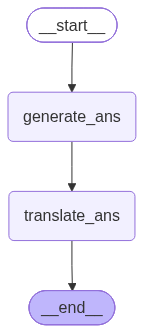

In [13]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
from typing import TypedDict
load_dotenv()

class subgraph_state(TypedDict):
    input_text:str
    translate_text:str
    
subgraph_llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash")
def translate_text(state:subgraph_state):
    prompt=f"""translate the text in hindi keep it simple and natural donot add extra content
    text={state['input_text']}""".strip()
    translate_text=subgraph_llm.invoke(prompt).content
    return {'translate_text':translate_text}
graph=StateGraph(subgraph_state)
graph.add_node('translate_text',translate_text)
graph.add_edge(START,'translate_text')
graph.add_edge('translate_text',END)

subgraph=graph.compile()

class parent_state(TypedDict):
    question:str
    answer_eng:str
    answer_hindi:str
    
    
parent_llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash")

def generate_ans(state: parent_state):
    prompt=f"""you are a helpful assistant answer clearly 
    question:{state['question']}"""
    answer=parent_llm.invoke(prompt).content
    return {'answer_eng':answer}
def translate_ans(state:parent_state):
    result=subgraph.invoke({"input_text":state['answer_eng']})
    return {'answer_hindi':result['translate_text']}

builder=StateGraph(parent_state)
builder.add_node('generate_ans',generate_ans)
builder.add_node('translate_ans',translate_ans)
builder.add_edge(START,'generate_ans')
builder.add_edge('generate_ans','translate_ans')
builder.add_edge('translate_ans',END)

res=builder.compile()
result=res.invoke({"question":"what is llm"})

print("\nHindi Answer:")
print(result["answer_hindi"])
print(result)

from IPython.display import Image
display(Image(res.get_graph().draw_mermaid_png()))




